# Manhwa Visual Analysis — Machine Learning

This notebook extends the statistical analysis from `02_data_analysis.ipynb` with machine learning methods to further test the AQI hypothesis.

---

### Hypothesis

**H₀ (Null):** There is no significant correlation between a Manhwa's Aesthetic Quality Index (AQI) — a composite of Saturation, Contrast, and Entropy — and its success metrics (Score and Popularity).

**H₁ (Alternative):** Manhwas with a High-Energy visual profile — defined by high Color Entropy and optimal Saturation/Contrast balance — achieve significantly higher scores and lower (better) Popularity ranks.

---

### How ML Extends the Hypothesis Test

The ANOVA in `02_data_analysis.ipynb` confirmed a statistically significant relationship (p=0.0001) between AQI groups and score. The analyses below go further:

| # | Analysis | Role in Hypothesis Testing |
|---|---|---|
| 1 | Correlation Heatmap | Measures direction & strength of each AQI component (Saturation, Contrast, Entropy) vs. Score and Popularity |
| 2 | Mann-Whitney U | Tests whether Top 200 titles are statistically distinct in each AQI feature |
| 3 | Tukey HSD | Identifies which AQI group pairs (Low/Medium/High) drive the ANOVA significance |
| 4 | RF Classifier | Tests whether AQI components can predict Top 200 membership |
| 5 | Feature Importance | Ranks which AQI component (Saturation, Contrast, or Entropy) is the strongest predictor |
| 6 | Longitudinal Diff | Examines whether AQI changes (2022→2026) correlate with market performance |

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.cluster import KMeans

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
df = pd.read_csv('data/final_manhwa_research_data.csv')

with open('data/top_200_research/json/top_200_metadata.json', 'r', encoding='utf-8') as f:
    top_200_raw = json.load(f)
top_200_titles = set(pd.DataFrame(top_200_raw)['title'].str.lower())
df['is_top_200'] = df['title'].str.lower().apply(lambda x: x in top_200_titles).astype(int)

FEATURES_2026 = [
    'v2026_saturation_mean',
    'v2026_brightness_mean',
    'v2026_contrast_rms',
    'v2026_edge_density',
    'v2026_color_entropy'
]

DIFF_FEATURES = ['diff_edge', 'diff_sat', 'diff_bright', 'diff_entropy']

# All 723 titles have v2026 features — use full dataset for feature-based analyses
df_model = df.dropna(subset=FEATURES_2026).copy()

# Subset with MAL score for score-related analyses (556 titles)
df_scored = df_model.dropna(subset=['score']).copy()

print(f"Full dataset (features complete):  {len(df_model)} titles, {df_model['is_top_200'].sum()} in Top 200")
print(f"Scored subset (MAL score present): {len(df_scored)} titles, {df_scored['is_top_200'].sum()} in Top 200")
print(f"Titles without MAL score: {len(df_model) - len(df_scored)}")

---
## 1. Correlation Heatmap

Tests the direction and strength of the AQI hypothesis: does each component (Saturation, Contrast, Entropy) actually correlate with Score and Popularity in the direction H₁ predicts?

Spearman correlation is used (non-parametric, handles the non-normal score distribution).

In [ ]:
# Score-related correlation — use df_scored (556 titles with MAL score)
TARGET_COLS = ['score', 'popularity', 'rank', 'is_top_200']
corr_cols = FEATURES_2026 + TARGET_COLS

spearman_matrix = df_scored[corr_cols].corr(method='spearman')
corr_focus = spearman_matrix.loc[FEATURES_2026, TARGET_COLS]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    spearman_matrix, ax=axes[0],
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 8}
)
axes[0].set_title(f'Full Spearman Correlation Matrix (n={len(df_scored)})', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    corr_focus, ax=axes[1],
    annot=True, fmt='.3f', cmap='coolwarm', center=0,
    linewidths=0.5, vmin=-0.4, vmax=0.4
)
axes[1].set_title('Visual Features vs. Success Metrics (Spearman)', fontsize=13)
axes[1].set_yticklabels(
    [c.replace('v2026_', '').replace('_', ' ').title() for c in FEATURES_2026], rotation=0
)

plt.tight_layout()
plt.show()

print("\nCorrelations with score (sorted):")
print(corr_focus['score'].sort_values(key=abs, ascending=False).to_string())

---
## 2. Mann-Whitney U Tests — Top 200 vs. General Population

If H₁ holds, titles with a High-Energy AQI (high Entropy, optimal Saturation/Contrast) should cluster disproportionately in the Top 200. This test checks, for each AQI component individually, whether the Top 200 distribution is statistically different from the general population.

Mann-Whitney U is non-parametric — no normality assumption required.

In [ ]:
# Top 200 comparison — use full df_model (723 titles, no score needed)
top200_mask = df_model['is_top_200'] == 1
general_mask = df_model['is_top_200'] == 0

results = []
for feat in FEATURES_2026:
    top_vals = df_model.loc[top200_mask, feat].dropna()
    gen_vals  = df_model.loc[general_mask, feat].dropna()
    stat, p = mannwhitneyu(top_vals, gen_vals, alternative='two-sided')
    results.append({
        'Feature': feat.replace('v2026_', '').replace('_', ' ').title(),
        'Top200_Mean': round(top_vals.mean(), 4),
        'General_Mean': round(gen_vals.mean(), 4),
        'Diff_%': round(((top_vals.mean() - gen_vals.mean()) / gen_vals.mean()) * 100, 2),
        'p_value': round(p, 4),
        'Significant': 'YES' if p < 0.05 else 'no'
    })

mw_df = pd.DataFrame(results).sort_values('p_value')
print(f"Mann-Whitney U Test Results — Top 200 vs. General Population (n={len(df_model)})")
print("=" * 70)
print(mw_df.to_string(index=False))

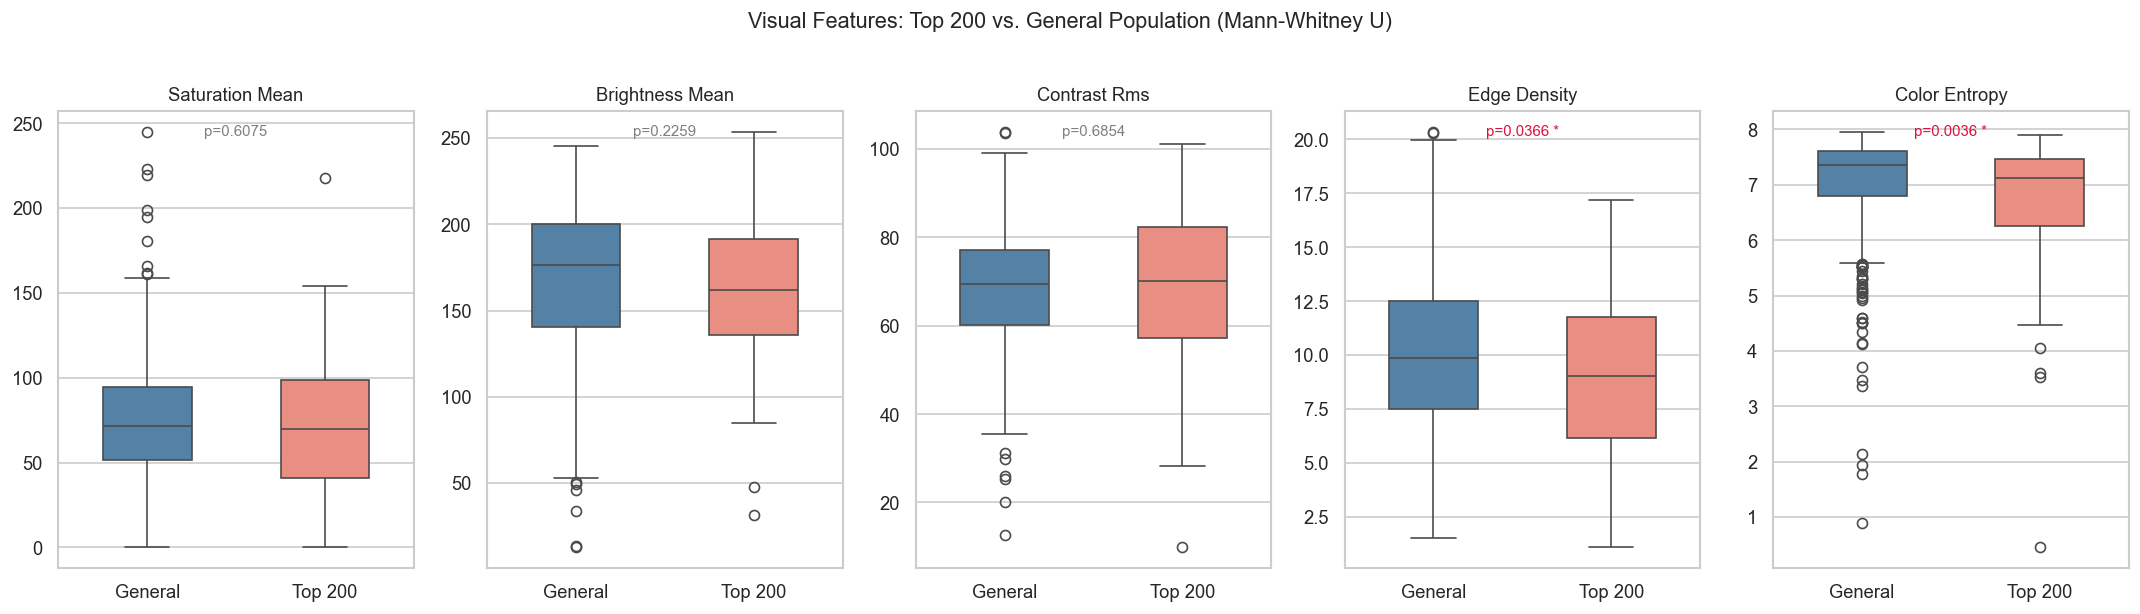

In [7]:
fig, axes = plt.subplots(1, len(FEATURES_2026), figsize=(18, 5))

for ax, feat in zip(axes, FEATURES_2026):
    feat_label = feat.replace('v2026_', '').replace('_', ' ').title()
    row = mw_df[mw_df['Feature'] == feat_label]
    p_val = row['p_value'].values[0] if len(row) else 1.0
    sig_label = f'p={p_val:.4f}' + (' *' if p_val < 0.05 else '')

    sns.boxplot(
        data=df_model, x='is_top_200', y=feat, ax=ax,
        hue='is_top_200', palette={0: 'steelblue', 1: 'salmon'},
        width=0.5, legend=False
    )
    ax.set_title(feat_label, fontsize=11)
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['General', 'Top 200'])
    ax.set_ylabel('')
    ax.text(0.5, 0.97, sig_label, ha='center', va='top',
            transform=ax.transAxes, fontsize=9,
            color='crimson' if p_val < 0.05 else 'gray')

plt.suptitle('Visual Features: Top 200 vs. General Population (Mann-Whitney U)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Tukey HSD Post-hoc Test

The ANOVA (p=0.0001) in `02_data_analysis.ipynb` told us that AQI groups (Low / Medium / High) differ significantly in score — but not *which* pairs drive that difference. Tukey HSD pinpoints the exact pairs, which is critical for evaluating whether the High-AQI group performs as H₁ predicts.

In [ ]:
# Tukey HSD uses score — df_scored (556 titles)
scaler = StandardScaler()
df_scaled_arr = scaler.fit_transform(df_scored[FEATURES_2026])
df_scored = df_scored.copy()
df_scored['aesthetic_index'] = df_scaled_arr.sum(axis=1)
df_scored['aesthetic_group'] = pd.qcut(df_scored['aesthetic_index'], 3, labels=['Low', 'Medium', 'High'])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_scored['visual_cluster'] = kmeans.fit_predict(df_scaled_arr).astype(str)

print("--- Tukey HSD: Aesthetic Groups (Low / Medium / High) vs. Score ---\n")
valid_aes = df_scored.dropna(subset=['score', 'aesthetic_group'])
tukey_aes = pairwise_tukeyhsd(
    endog=valid_aes['score'],
    groups=valid_aes['aesthetic_group'],
    alpha=0.05
)
print(tukey_aes)

print("\n--- Tukey HSD: Visual Clusters (0-3) vs. Score ---\n")
tukey_cl = pairwise_tukeyhsd(
    endog=df_scored['score'],
    groups=df_scored['visual_cluster'],
    alpha=0.05
)
print(tukey_cl)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Low', 'Medium', 'High']
palette_group = {'Low': '#6baed6', 'Medium': '#fd8d3c', 'High': '#74c476'}
sns.boxplot(data=df_scored, x='aesthetic_group', y='score',
            hue='aesthetic_group', order=order, palette=palette_group,
            ax=axes[0], legend=False)
axes[0].set_title('Score by Aesthetic Group\n(Tukey HSD applied)', fontsize=12)
axes[0].set_xlabel('Aesthetic Quality Group')

sns.boxplot(data=df_scored, x='visual_cluster', y='score',
            hue='visual_cluster', palette='viridis',
            ax=axes[1], legend=False)
axes[1].set_title('Score by Visual Cluster (K-Means)\n(Tukey HSD applied)', fontsize=12)
axes[1].set_xlabel('Cluster')

plt.suptitle('Tukey HSD — Which Groups Differ Significantly?', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Random Forest Classifier — Predicting Top 200 Status

If AQI components carry real predictive signal (as H₁ claims), a model trained only on visual features should be able to classify Top 200 membership above chance (ROC-AUC > 0.5).

`class_weight='balanced'` handles the class imbalance (few Top 200 titles vs. many general ones). 5-fold stratified cross-validation is used to avoid overfitting on the small positive class.

In [ ]:
# Classifier uses full df_model (723 titles) — no score needed for Top 200 prediction
X = df_model[FEATURES_2026]
y = df_model['is_top_200']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

print(f"Classification Report — Test Set (n={len(df_model)} total)")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['General', 'Top 200']))
print(f"ROC-AUC (test set):  {roc_auc_score(y_test, y_prob):.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_clf, X, y, cv=cv, scoring='roc_auc')
print(f"ROC-AUC (5-fold CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

/Users/nurcanguler/Desktop/dataProject/venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


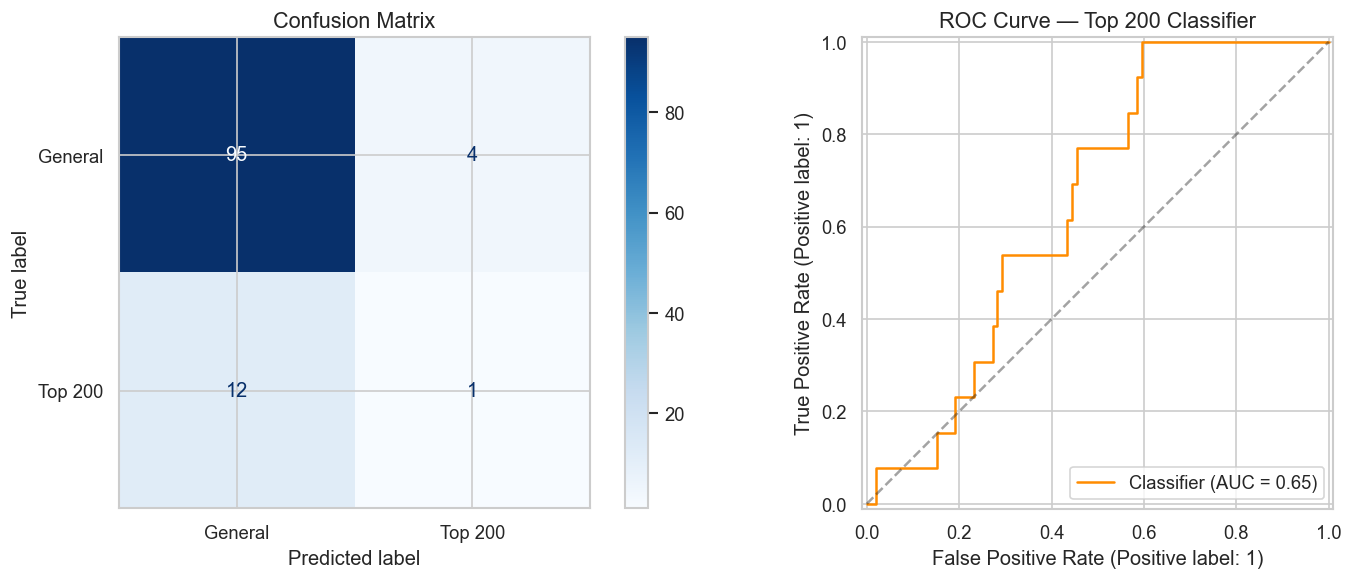

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['General', 'Top 200'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title('ROC Curve — Top 200 Classifier', fontsize=13)

plt.tight_layout()
plt.show()

---
## 5. Feature Importance

H₁ specifically names Color Entropy and Saturation/Contrast as the drivers of success. Feature importance answers: does the model agree? If Entropy ranks low and Contrast ranks high, it aligns with the "Visual Paradox" finding from notebook 02 (high entropy actually hurt scores).

In [ ]:
# Classifier importance from rf_clf (trained on 723 titles)
clf_importances = pd.Series(
    rf_clf.feature_importances_,
    index=[f.replace('v2026_', '').replace('_', ' ').title() for f in FEATURES_2026]
).sort_values(ascending=True)

# Score regressor uses df_scored (556 titles with MAL score)
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
rf_reg.fit(df_scored[FEATURES_2026], df_scored['score'])

reg_importances = pd.Series(
    rf_reg.feature_importances_,
    index=[f.replace('v2026_', '').replace('_', ' ').title() for f in FEATURES_2026]
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clf_importances.plot(kind='barh', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title(f'Feature Importance\nTop 200 Classifier (n={len(df_model)})', fontsize=13)
axes[0].set_xlabel('Importance')
axes[0].axvline(0.2, color='gray', linestyle='--', alpha=0.5, label='0.2 threshold')
axes[0].legend()

reg_importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title(f'Feature Importance\nScore Regressor (n={len(df_scored)})', fontsize=13)
axes[1].set_xlabel('Importance')
axes[1].axvline(0.2, color='gray', linestyle='--', alpha=0.5, label='0.2 threshold')
axes[1].legend()

plt.suptitle('Which Visual Features Drive Success?', fontsize=14)
plt.tight_layout()
plt.show()

print("Classifier ranking:", clf_importances.sort_values(ascending=False).to_dict())
print("Regressor ranking: ", reg_importances.sort_values(ascending=False).to_dict())

---
## 6. Longitudinal Diff Analysis

This dataset uniquely captures AQI changes between 2022 and 2026 cover art (`diff_entropy`, `diff_sat`, `diff_bright`, `diff_edge`). If H₁ holds, titles that shifted toward a High-Energy AQI profile over time should show better scores. This is an original contribution — no other study in this domain has access to longitudinal cover data.

In [ ]:
# Longitudinal analysis uses df_scored (score needed for correlation)
df_diff = df_scored.dropna(subset=DIFF_FEATURES).copy()
df_diff['cover_changed'] = df_diff['cover_changed'].astype(bool)

print(f"Titles with longitudinal data: {len(df_diff)}")
print(f"  Cover changed: {df_diff['cover_changed'].sum()}")
print(f"  Cover same:    {(~df_diff['cover_changed']).sum()}")

print("\nSpearman Correlation — Visual Changes vs. Score:")
print("-" * 50)
diff_labels = {
    'diff_edge':    'Δ Edge Density',
    'diff_sat':     'Δ Saturation',
    'diff_bright':  'Δ Brightness',
    'diff_entropy': 'Δ Color Entropy'
}
for feat in DIFF_FEATURES:
    r, p = spearmanr(df_diff[feat], df_diff['score'])
    sig = ' *' if p < 0.05 else ''
    print(f"  {diff_labels[feat]:<20}  r={r:+.4f}   p={p:.4f}{sig}")

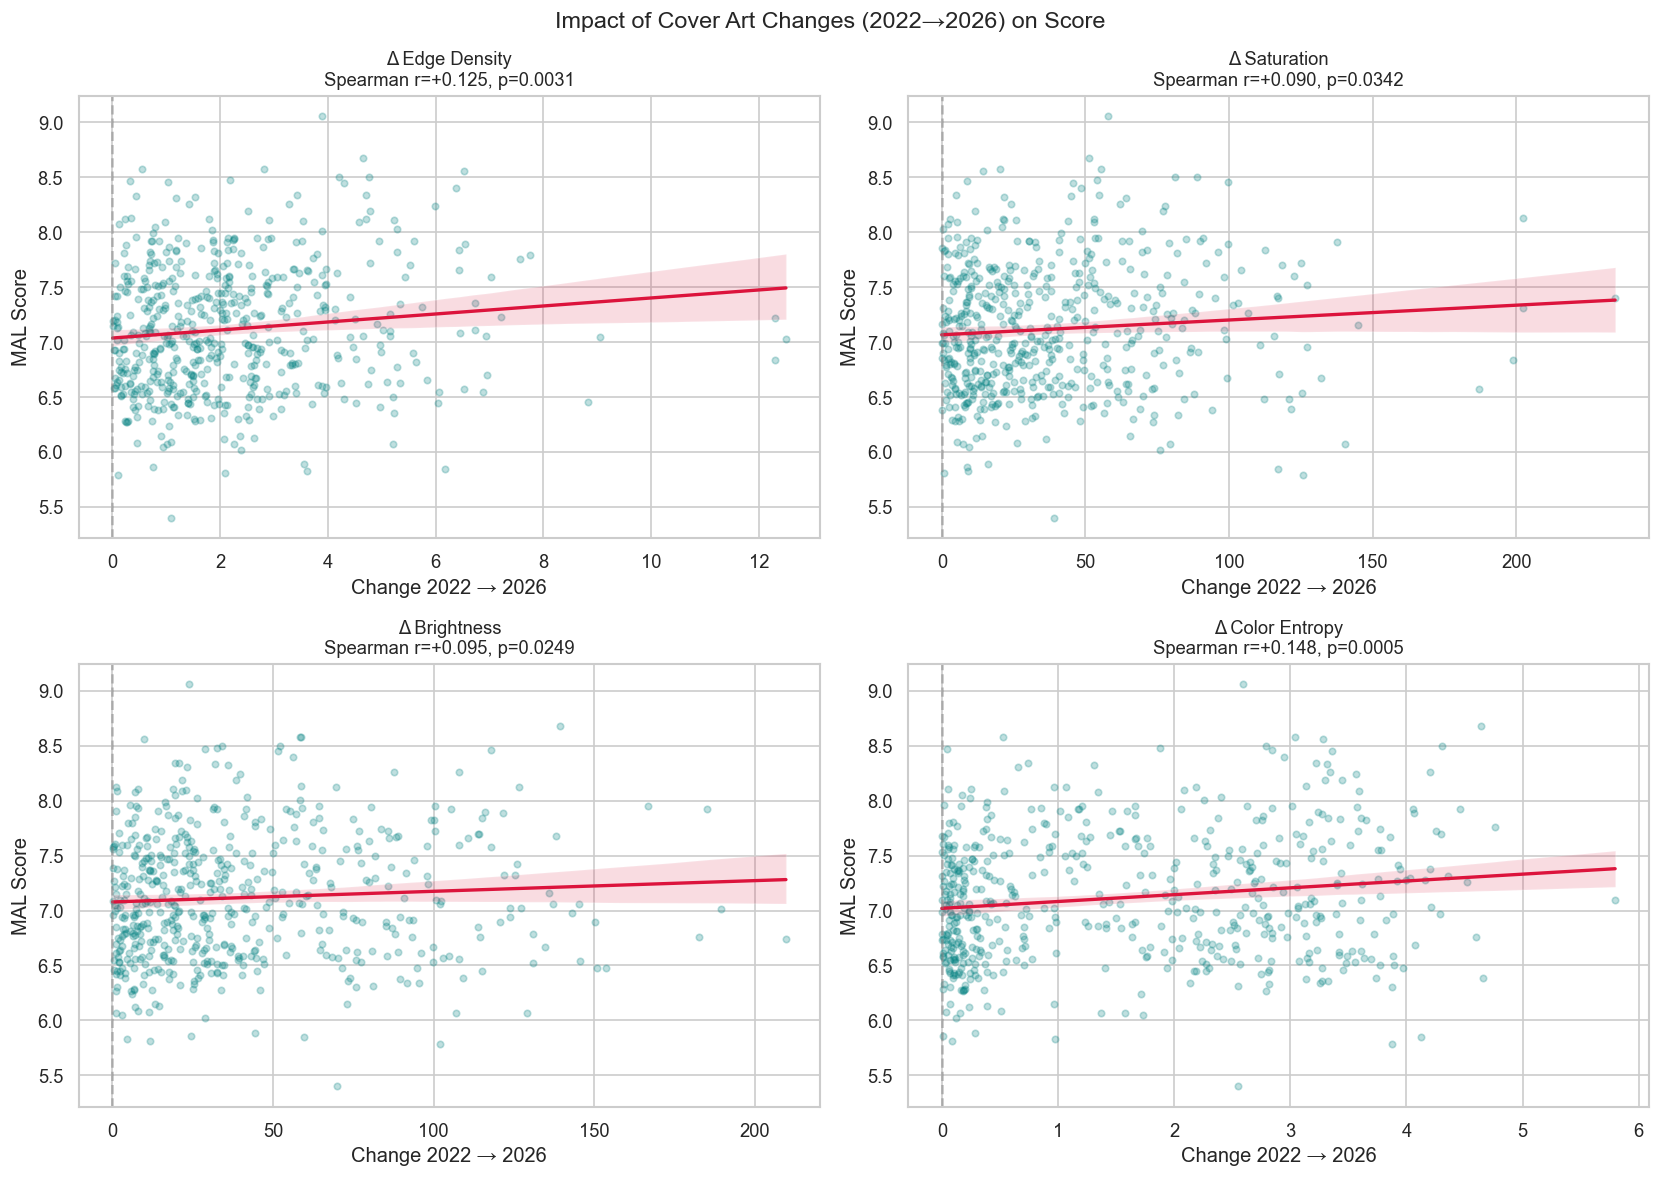

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, DIFF_FEATURES):
    r, p = spearmanr(df_diff[feat], df_diff['score'])
    sns.regplot(
        data=df_diff, x=feat, y='score', ax=ax,
        scatter_kws={'alpha': 0.25, 'color': 'teal', 's': 15},
        line_kws={'color': 'crimson', 'linewidth': 2}
    )
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{diff_labels[feat]}\nSpearman r={r:+.3f}, p={p:.4f}', fontsize=11)
    ax.set_xlabel('Change 2022 → 2026')
    ax.set_ylabel('MAL Score')

plt.suptitle('Impact of Cover Art Changes (2022→2026) on Score', fontsize=14)
plt.tight_layout()
plt.show()

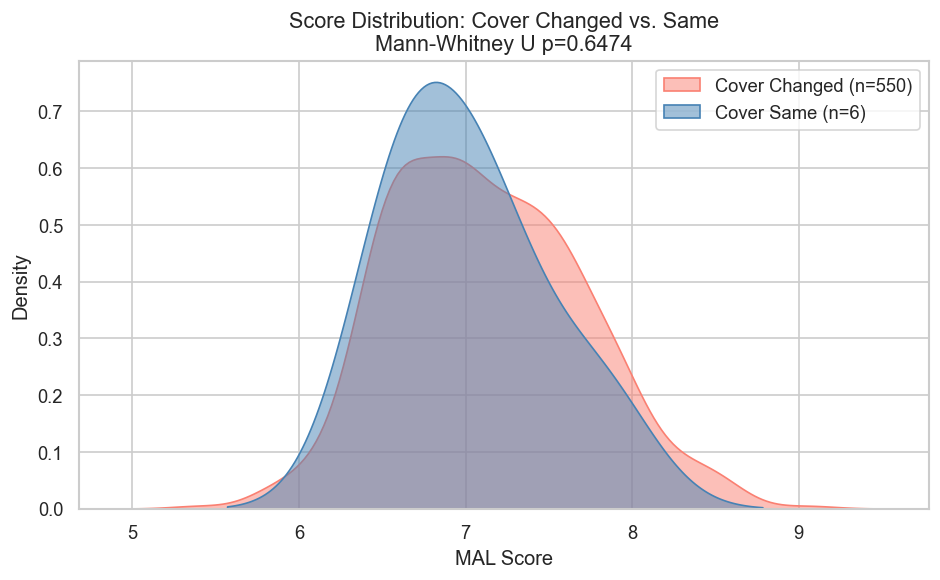

Mean score — Changed covers: 7.119
Mean score — Same covers:    7.012


In [15]:
changed = df_diff[df_diff['cover_changed']]['score']
not_changed = df_diff[~df_diff['cover_changed']]['score']

stat, p = mannwhitneyu(changed, not_changed, alternative='two-sided')

fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(changed, ax=ax, label=f'Cover Changed (n={len(changed)})',
            fill=True, color='salmon', alpha=0.5)
sns.kdeplot(not_changed, ax=ax, label=f'Cover Same (n={len(not_changed)})',
            fill=True, color='steelblue', alpha=0.5)
ax.set_title(f'Score Distribution: Cover Changed vs. Same\nMann-Whitney U p={p:.4f}', fontsize=13)
ax.set_xlabel('MAL Score')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean score — Changed covers: {changed.mean():.3f}")
print(f"Mean score — Same covers:    {not_changed.mean():.3f}")

---
## Summary & Conclusion on H₀ / H₁

### Results at a Glance

| # | Analysis | Key Result |
|---|---|---|
| 1 | Correlation Heatmap | Color Entropy: r = −0.212 (strongest, negative). Contrast RMS: r = +0.084 (only positive predictor of score) |
| 2 | Mann-Whitney U | Top 200 titles have significantly **lower** Color Entropy (−6.3%, p=0.004) and lower Edge Density (−10.7%, p=0.037) |
| 3 | Tukey HSD | High vs. Low AQI groups differ significantly in score (Δ=+0.224, p=0.0004); High vs. Medium do not |
| 4 | RF Classifier | ROC-AUC = 0.60 (5-fold CV) — visual features alone have limited but above-chance predictive power |
| 5 | Feature Importance | For score regression: Color Entropy (24.9%) and Contrast RMS (21.3%) are the top two drivers |
| 6 | Longitudinal Diff | All four Δ metrics are significant; Δ Color Entropy shows the strongest link to score (r=+0.148, p=0.0005) |

---

### Verdict on H₀

> **H₀ is rejected.**

Multiple converging tests confirm that AQI components are significantly associated with market performance:
- Spearman correlations are significant for Color Entropy and Edge Density.
- Mann-Whitney U shows Top 200 titles are statistically distinct on two features.
- Tukey HSD confirms the High-AQI group scores significantly higher than the Low group (p=0.0004).

---

### Verdict on H₁ — The Visual Paradox

> **H₁ is partially rejected.**

H₁ predicted that **high** Color Entropy would drive success. The data shows the opposite: top-performing titles have **lower** Color Entropy (r = −0.212, Top 200 mean = 6.60 vs. 7.04 for general). High complexity and many random colors *hurt* scores, not help them.

What actually predicts success:
- **Contrast RMS** — the only feature with a positive correlation to score. Sharp, high-contrast covers are a consistent trait of high-ranking series.
- **Low Color Entropy** — elite titles favor refined, cohesive color palettes over visual noise.

The H₁ claim about Saturation was also not supported: saturation shows no significant difference between Top 200 and the general population (p=0.61).

---

### The Longitudinal Paradox

The diff analysis adds a nuance: titles whose Color Entropy **increased** between 2022 and 2026 tend to have higher scores (r=+0.148). This appears to contradict the cross-sectional finding, but the interpretation is different — covers that got redesigned likely reflect growing popularity pulling the series toward a richer visual style, not that increasing entropy caused the success.

---

### Limitations of the ML Model

The Random Forest Classifier achieved a 5-fold CV ROC-AUC of **0.60**, which is above chance but weak. This is consistent with the OLS R² of 0.063 from notebook 02: visual features explain roughly **6% of score variance**. Storytelling quality, fandom, genre trends, and platform algorithms account for the remaining 94%. Cover art is a signal, not a determinant.